# 01 — Exploration du graphe des aéroports

**Objectif.** Caractériser le graphe avant toute modélisation, afin que chaque choix ultérieur (prétraitement, architecture, protocole d'évaluation) repose sur une observation.

**Méthode.** L'exploration est organisée en sept questions (Q0 à Q6). Pour chacune :
1. la question et l'hypothèse sont formulées **avant** l'exécution ;
2. le calcul est effectué ;
3. le résultat est interprété et traduit en décision.

Aucune donnée n'est corrigée dans ce notebook : les problèmes sont uniquement recensés. Le nettoyage sera réalisé par `src/clean.py`.

## Configuration

In [1]:
import os, re, html, collections
from pathlib import Path
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from scipy import stats

SEED = 0
rng = np.random.default_rng(SEED)

# Chemin du fichier brut (à adapter si besoin)
CANDIDATES = [
    Path("../data/airports.graphml.xml"),
    Path("data/airports.graphml.xml"),
    Path("../data/raw/airports.graphml.xml"),
    Path("data/raw/airportsAndCoordAndPop.graphml.xml"),
    Path("airportsAndCoordAndPop.graphml.xml"),
    Path("/mnt/user-data/uploads/airportsAndCoordAndPop_graphml.xml"),
]
RAW = next(p for p in CANDIDATES if p.exists())
FIG = Path("figures"); FIG.mkdir(exist_ok=True)

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.width", 140)
print("Fichier :", RAW)

Fichier : /mnt/user-data/uploads/airportsAndCoordAndPop_graphml.xml


In [2]:
def haversine(lat1, lon1, lat2, lon2):
    """Distance orthodromique en km (vectorisée)."""
    lat1, lon1, lat2, lon2 = map(np.radians, (lat1, lon1, lat2, lon2))
    a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 2 * 6371.0 * np.arcsin(np.sqrt(a))

## Q0 — Le fichier est-il fiable tel que chargé ?

*Contrôle d'intégrité, pas une hypothèse.* On vérifie : nombre de nœuds et d'arêtes, boucles, doublons, valeurs manquantes, numérotation des identifiants et format des pays.

**Attendu :** un graphe non orienté sans boucle, des identifiants non contigus, quelques chaînes de pays mal formées.

In [3]:
G = nx.read_graphml(RAW)
print(f"Orienté : {G.is_directed()}  |  Nœuds : {G.number_of_nodes()}  |  Arêtes : {G.number_of_edges()}")
print("Boucles (self-loops) :", nx.number_of_selfloops(G))

# Doublons : NetworkX fusionne les arêtes en double d'un Graph ; on compte donc les <edge> du XML brut
raw_text = RAW.read_text(encoding="utf-8")
raw_edges = re.findall(r'<edge source="(\d+)" target="(\d+)"', raw_text)
undirected = collections.Counter(tuple(sorted(e)) for e in raw_edges)
print("Balises <edge> dans le fichier :", len(raw_edges))
print("Paires présentes plusieurs fois :", sum(1 for c in undirected.values() if c > 1))

Orienté : False  |  Nœuds : 3363  |  Arêtes : 13547
Boucles (self-loops) : 0
Balises <edge> dans le fichier : 13547
Paires présentes plusieurs fois : 0


In [4]:
nodes = pd.DataFrame.from_dict(dict(G.nodes(data=True)), orient="index")
nodes.index.name = "id"
nodes["degree"] = pd.Series(dict(G.degree()))
print(nodes.dtypes, "\n")
print("Valeurs manquantes par attribut :\n", nodes.isna().sum(), "\n")

ids = sorted(int(i) for i in G.nodes)
missing_ids = sorted(set(range(ids[0], ids[-1] + 1)) - set(ids))
print(f"Identifiants de {ids[0]} à {ids[-1]} ; {len(missing_ids)} numéros absents : {missing_ids[:15]}")
nodes.describe()

lon           float64
lat           float64
population      int64
country           str
city_name         str
degree          int64
dtype: object 

Valeurs manquantes par attribut :
 lon           0
lat           0
population    0
country       0
city_name     0
degree        0
dtype: int64 

Identifiants de 0 à 3372 ; 10 numéros absents : [2408, 2951, 3206, 3207, 3211, 3213, 3249, 3305, 3325, 3360]


,lon,lat,population,degree
count,3363.000000,3363.000000,3.363000e+03,3363.000000
mean,0.696037,23.022150,3.380776e+05,8.056497
std,96.474538,29.334014,1.262323e+06,18.188183
min,-179.866667,-54.816667,6.370000e+02,1.000000
25%,-81.440834,-0.966667,1.000000e+04,2.000000
50%,6.108889,30.121944,1.506100e+04,3.000000
75%,85.866667,45.796748,1.554095e+05,6.000000
max,179.900000,78.245278,2.231547e+07,248.000000


In [5]:
# Chaînes de pays mal formées (entités HTML, variantes séparées par #)
malformed = sorted(c for c in nodes["country"].unique() if "&" in c or "#" in c)
print(f"{len(malformed)} chaînes de pays mal formées :")
for c in malformed:
    print(f"  {c!r:55} -> {c.split('#')[-1].split(',')[0]!r}")

9 chaînes de pays mal formées :
  'HA&Iuml;TI#HAITI'                                      -> 'HAITI'
  'M&Eacute;XICO#MEXICO'                                  -> 'MEXICO'
  'PER&Uacute;#PERU'                                      -> 'PERU'
  'SAINT-PIERRE_AND_MIQUELON#ST-PIERRE_AND_MIQUELON'      -> 'ST-PIERRE_AND_MIQUELON'
  'SAINT_HELENA#ST_HELENA'                                -> 'ST_HELENA'
  'SAINT_KITTS_AND_NEVIS#ST_KITTS_AND_NEVIS'              -> 'ST_KITTS_AND_NEVIS'
  'SAINT_LUCIA#ST_LUCIA'                                  -> 'ST_LUCIA'
  'SAINT_VINCENT_AND_THE_GRENADINES#ST_VINCENT_AND_THE_GRENADINES' -> 'ST_VINCENT_AND_THE_GRENADINES'
  'VI&Ecirc;T_NAM#VIET_NAM,VIETNAM'                       -> 'VIET_NAM'


In [6]:
def clean_country(c):
    return html.unescape(c).split("#")[-1].split(",")[0]

nodes["country_clean"] = nodes["country"].map(clean_country)
print("Pays distincts (bruts / nettoyés) :", nodes["country"].nunique(), "/", nodes["country_clean"].nunique())

Pays distincts (bruts / nettoyés) : 212 / 211


### Observation → décision (Q0)

**Observations.**
- Le graphe est non orienté et contient 3 363 nœuds et 13 547 arêtes, sans boucle ni arête dupliquée.
- Aucun attribut ne présente de valeur manquante au sens strict ; la population comporte toutefois une valeur par défaut, traitée en Q5.
- Les identifiants vont de 0 à 3 372 et 10 numéros sont absents : ils ne peuvent donc pas servir directement d'indices.
- Neuf chaînes de pays sont mal formées (entités HTML, variantes séparées par `#` ou par une virgule). Après normalisation, on obtient 211 pays au lieu de 212, le Viêt Nam apparaissant sous deux graphies.

**Décisions.**
- Réindexer les nœuds de 0 à N−1 et conserver une table de correspondance identifiant d'origine → index → ville, nécessaire pour interpréter les prédictions.
- Normaliser les pays par décodage HTML puis conservation de la partie située après `#` (règle `clean_country`).
- Aucune arête n'est à supprimer.

## Q1 — Le graphe est-il « facile » pour une prédiction de liens fondée sur la structure locale ?

**Hypothèse :** les réseaux aériens comportent beaucoup de triangles ; les heuristiques de voisins communs seront donc déjà performantes.

**Test :** comparer le coefficient de clustering à celui d'un graphe aléatoire de même taille (modèle d'Erdős–Rényi G(n, m)), et mesurer l'assortativité de degré.

In [7]:
n, m = G.number_of_nodes(), G.number_of_edges()
density = nx.density(G)
clust = nx.average_clustering(G)
trans = nx.transitivity(G)

G_rand = nx.gnm_random_graph(n, m, seed=SEED)
clust_rand = nx.average_clustering(G_rand)

assort = nx.degree_assortativity_coefficient(G)

pd.DataFrame({
    "valeur": [density, clust, trans, clust_rand, clust / clust_rand, assort],
}, index=["densité", "clustering moyen", "transitivité", "clustering G(n,m) aléatoire",
          "ratio réel / aléatoire", "assortativité de degré"]).round(4)

,valeur
densité,0.0024
clustering moyen,0.4932
transitivité,0.2477
"clustering G(n,m) aléatoire",0.0022
ratio réel / aléatoire,219.5984
assortativité de degré,0.0401


### Observation → décision (Q1)

**Observations.**
- Le coefficient de clustering moyen (0,49) est environ 220 fois supérieur à celui d'un graphe aléatoire G(n, m) de même taille (0,002). L'hypothèse est confirmée : le graphe est riche en triangles.
- L'écart entre clustering moyen (0,49) et transitivité (0,25) indique que les nœuds de faible degré sont fortement regroupés, tandis que les hubs, aux voisinages très étendus, le sont moins.
- L'assortativité de degré est quasi nulle (0,04). **L'hypothèse d'une structure hub-and-spoke (assortativité négative) n'est pas confirmée** : le réseau mêle vraisemblablement un cœur de hubs interconnectés et des réseaux régionaux.

**Décisions.**
- Les heuristiques fondées sur les voisins communs (Common Neighbors, Adamic-Adar) constituent des baselines sérieuses ; un modèle GNN ne sera jugé pertinent que s'il les dépasse.
- Le résultat sur l'assortativité sera mentionné dans le rapport comme hypothèse réfutée.

## Q2 — Le réseau est-il dominé par des hubs, et combien d'aéroports sont « fragiles » ?

**Hypothèse :** distribution des degrés à queue lourde ; beaucoup d'aéroports de degré 1.

**Test :** distribution des degrés en échelle log-log, principaux hubs, nœuds de degré 1, composantes connexes.

In [8]:
deg = nodes["degree"]
print(f"Degré moyen {deg.mean():.2f} | médian {deg.median():.0f} | max {deg.max()}")
for k in (1, 2, 3):
    print(f"Nœuds de degré {k} : {(deg == k).sum()} ({(deg == k).mean():.1%})")
print("\nTop 10 des hubs :")
nodes.sort_values("degree", ascending=False)[["city_name", "country_clean", "degree"]].head(10)

Degré moyen 8.06 | médian 3 | max 248
Nœuds de degré 1 : 725 (21.6%)
Nœuds de degré 2 : 869 (25.8%)
Nœuds de degré 3 : 445 (13.2%)

Top 10 des hubs :


,city_name,country_clean,degree
id,,,
165,Paris,FRANCE,248
144,London,UNITED_KINGDOM,240
133,Frankfurt,GERMANY,234
106,Amsterdam,THE_NETHERLANDS,191
66,Chicago,USA,183
156,Moscow,RUSSIA,179
86,New York,USA,178
65,Atlanta,USA,171
67,Dallas/Fort Worth,USA,147


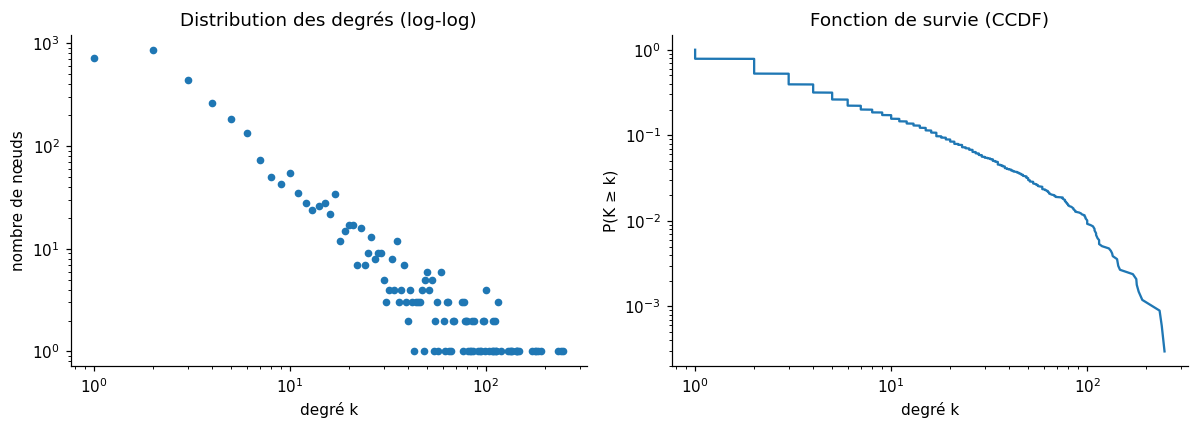

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
counts = deg.value_counts().sort_index()
axes[0].loglog(counts.index, counts.values, "o", ms=4)
axes[0].set(xlabel="degré k", ylabel="nombre de nœuds", title="Distribution des degrés (log-log)")

k_sorted = np.sort(deg.values)
ccdf = 1 - np.arange(len(k_sorted)) / len(k_sorted)
axes[1].loglog(k_sorted, ccdf)
axes[1].set(xlabel="degré k", ylabel="P(K ≥ k)", title="Fonction de survie (CCDF)")
plt.tight_layout(); plt.savefig(FIG / "fig_degree_distribution.pdf"); plt.show()

In [10]:
comps = sorted(nx.connected_components(G), key=len, reverse=True)
print("Tailles des composantes :", [len(c) for c in comps])
print(f"Composante géante : {len(comps[0]) / n:.1%} des nœuds\n")
for c in comps[1:]:
    print(sorted(nodes.loc[list(c), "city_name"] + " (" + nodes.loc[list(c), "country_clean"] + ")"))

Tailles des composantes : [3351, 4, 2, 2, 2, 2]
Composante géante : 99.6% des nœuds

['Black Tickle (CANADA)', 'Charlottetown (CANADA)', 'Port Hope Simpson (CANADA)', 'Williams Harbour (CANADA)']
['Darnley Island (AUSTRALIA)', 'Murray Island (AUSTRALIA)']
['Forbes (AUSTRALIA)', 'West Wyalong (AUSTRALIA)']
['Cootamundra (AUSTRALIA)', 'Young (AUSTRALIA)']
['Center Island (USA)', 'Decatur Island (USA)']


In [11]:
# Degré-1 : un split aléatoire qui cache leur unique route les rend isolés
share_edges_leaf = sum(1 for u, v in G.edges if G.degree(u) == 1 or G.degree(v) == 1) / m
print(f"Part des routes touchant un nœud de degré 1 : {share_edges_leaf:.1%}")
print("→ avec 10 % de test, environ", round(0.10 * (deg == 1).sum()), "aéroports deviendraient isolés dans le graphe d'entraînement")

Part des routes touchant un nœud de degré 1 : 5.3%
→ avec 10 % de test, environ 72 aéroports deviendraient isolés dans le graphe d'entraînement


### Observation → décision (Q2)

**Observations.**
- La distribution des degrés est à queue lourde : degré médian de 3, moyen de 8,06, maximal de 248 (Paris, Londres, Francfort). La CCDF s'infléchit vers le bas au-delà d'un degré d'environ 100, ce qui traduit une coupure : on parlera de distribution à queue lourde, sans affirmer de loi de puissance.
- 725 aéroports (21,6 %) sont de degré 1 et 47,4 % sont de degré 1 ou 2.
- La composante géante regroupe 3 351 nœuds (99,6 %) ; les cinq autres composantes sont de petits réseaux régionaux (Canada, Australie, États-Unis) de 2 à 4 nœuds.
- Avec 10 % d'arêtes de test, environ 72 aéroports perdraient leur unique route dans le graphe d'entraînement et deviendraient isolés.

**Décisions.**
- Ajouter la baseline Preferential Attachment, que la forte hétérogénéité des degrés rend compétitive.
- Restreindre l'étude à la composante géante (perte de 12 nœuds, négligeable).
- Lors du découpage, ne pas placer en validation ou en test l'unique arête d'un nœud de degré 1, afin qu'aucun nœud ne devienne isolé. Ce choix sera décrit dans le protocole expérimental.

## Q3 — Les routes dépendent-elles de la distance ?

**Hypothèse :** les routes réelles sont nettement plus courtes que des paires d'aéroports tirées au hasard. *C'est la question la plus importante pour la méthode.*

**Test :** distance haversine des routes existantes, comparée à celle d'un nombre égal de paires non reliées tirées uniformément.

In [12]:
lat = nodes["lat"]; lon = nodes["lon"]
E = np.array(list(G.edges))
d_edges = haversine(lat[E[:, 0]].values, lon[E[:, 0]].values, lat[E[:, 1]].values, lon[E[:, 1]].values)

# Paires aléatoires non reliées (négatifs « uniformes »)
node_ids = nodes.index.values
neg = set()
while len(neg) < m:
    u, v = rng.choice(node_ids, 2, replace=False)
    if not G.has_edge(u, v):
        neg.add(tuple(sorted((u, v))))
N = np.array(list(neg))
d_rand = haversine(lat[N[:, 0]].values, lon[N[:, 0]].values, lat[N[:, 1]].values, lon[N[:, 1]].values)

summary = pd.DataFrame({"routes": pd.Series(d_edges).describe(), "paires aléatoires": pd.Series(d_rand).describe()}).round(0)
ks = stats.ks_2samp(d_edges, d_rand)
print(f"Test de Kolmogorov-Smirnov : D = {ks.statistic:.3f}, p = {ks.pvalue:.1e}")
for t in (500, 1000, 2000):
    print(f"< {t} km : routes {np.mean(d_edges < t):.1%} | aléatoires {np.mean(d_rand < t):.1%}")
summary

Test de Kolmogorov-Smirnov : D = 0.713, p = 0.0e+00
< 500 km : routes 36.2% | aléatoires 0.6%
< 1000 km : routes 55.7% | aléatoires 2.0%
< 2000 km : routes 74.4% | aléatoires 6.2%


,routes,paires aléatoires
count,13547.0,13547.0
mean,1992.0,8981.0
std,3039.0,4486.0
min,3.0,116.0
25%,340.0,5455.0
50%,814.0,8958.0
75%,2059.0,12498.0
max,19802.0,19952.0


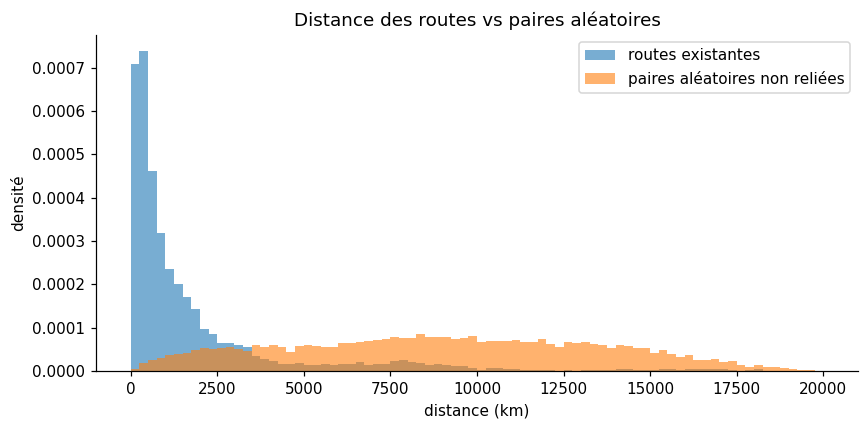

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
bins = np.linspace(0, 20000, 81)
ax.hist(d_edges, bins, alpha=.6, density=True, label="routes existantes")
ax.hist(d_rand, bins, alpha=.6, density=True, label="paires aléatoires non reliées")
ax.set(xlabel="distance (km)", ylabel="densité", title="Distance des routes vs paires aléatoires")
ax.legend(); plt.tight_layout(); plt.savefig(FIG / "fig_distance_edges_vs_random.pdf"); plt.show()

Spearman(degré, longueur moyenne des routes) = 0.470


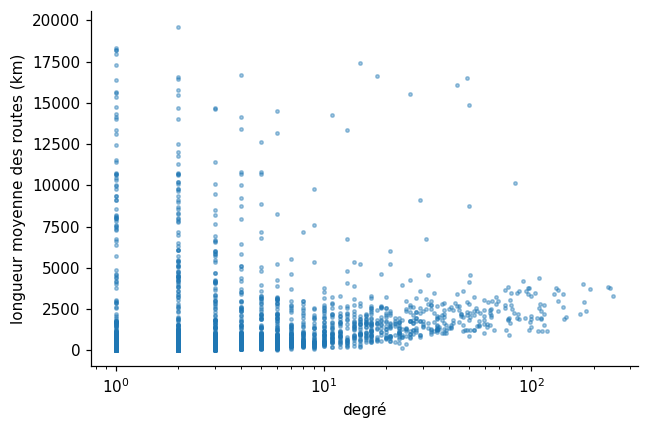

In [14]:
# Longueur des routes selon la taille de l'aéroport
node_dist = collections.defaultdict(list)
for (u, v), d in zip(E, d_edges):
    node_dist[u].append(d); node_dist[v].append(d)
nodes["mean_route_km"] = pd.Series({k: np.mean(v) for k, v in node_dist.items()})

rho = stats.spearmanr(nodes["degree"], nodes["mean_route_km"], nan_policy="omit")
print(f"Spearman(degré, longueur moyenne des routes) = {rho.statistic:.3f}")
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(nodes["degree"], nodes["mean_route_km"], s=5, alpha=.4)
ax.set(xscale="log", xlabel="degré", ylabel="longueur moyenne des routes (km)")
plt.tight_layout(); plt.show()

### Observation → décision (Q3)

**Observations.**
- Les distributions de distance des routes existantes et des paires aléatoires non reliées sont presque disjointes (Kolmogorov-Smirnov : D = 0,71, p < 10⁻³⁰⁰). La distance médiane d'une route est de 814 km, contre 8 958 km pour une paire aléatoire.
- 55,7 % des routes font moins de 1 000 km, contre 2,0 % des paires aléatoires. L'hypothèse est largement confirmée.
- La longueur moyenne des routes croît avec le degré (Spearman = 0,47) : les hubs desservent des liaisons long-courrier.
- Le nuage de points révèle cependant des aéroports de degré 1 ou 2 dont la longueur moyenne des routes dépasse 10 000 km, ce qui est invraisemblable pour des aéroports régionaux. Ces points correspondent aux erreurs de localisation étudiées en Q6 et biaisent en partie la corrélation.

**Décisions.**
- Ajouter une baseline « distance seule » au tableau comparatif : contre des négatifs aléatoires, elle devrait déjà atteindre une AUC élevée.
- Intégrer la distance haversine comme caractéristique de paire dans le décodeur.
- Évaluer également sur des **négatifs difficiles** (paires proches géographiquement mais non reliées) : avec des négatifs uniformes, la tâche se réduit presque à un test de distance et le tableau comparatif perd son pouvoir discriminant.

## Q4 — Les routes restent-elles à l'intérieur d'un pays ?

**Hypothèse :** une majorité de routes est domestique, bien au-delà de ce qu'on attendrait par hasard.

**Test :** proportion de routes entre deux aéroports d'un même pays, comparée à la probabilité qu'une paire aléatoire soit domestique.

In [15]:
cc = nodes["country_clean"]
domestic = (cc[E[:, 0]].values == cc[E[:, 1]].values)
p_country = cc.value_counts(normalize=True)
expected = (p_country ** 2).sum()
print(f"Routes domestiques : {domestic.mean():.1%}")
print(f"Attendu pour une paire aléatoire : {expected:.1%}  (ratio {domestic.mean() / expected:.1f}x)")

print(f"\nPays : {cc.nunique()} | pays avec un seul aéroport : {(cc.value_counts() == 1).sum()}")
cc.value_counts().head(10)

Routes domestiques : 57.4%
Attendu pour une paire aléatoire : 5.4%  (ratio 10.7x)

Pays : 211 | pays avec un seul aéroport : 62


country_clean
USA                 650
CANADA              243
AUSTRALIA           207
BRAZIL              105
CHINA                93
PAPUA_NEW_GUINEA     92
RUSSIA               70
JAPAN                69
MEXICO               59
ARGENTINA            57
Name: count, dtype: int64

### Observation → décision (Q4)

**Observations.**
- 57,4 % des routes relient deux aéroports d'un même pays, contre 5,4 % attendus pour une paire aléatoire, soit un facteur 10,7. L'hypothèse est confirmée.
- La répartition des aéroports par pays est très déséquilibrée (650 aux États-Unis, 62 pays avec un seul aéroport).

**Décisions.**
- Le pays est un attribut informatif.
- Un encodage one-hot sur 211 pays serait creux et peu généralisable compte tenu des 62 pays à un seul nœud. On retient en priorité une caractéristique de paire « même pays » dans le décodeur ; un embedding appris du pays pourra être comparé. L'apport de cet attribut sera mesuré dans l'étude d'ablation.

## Q5 — Peut-on faire confiance à l'attribut population ?

**Hypothèse :** la population est bruitée et en partie manquante (valeur par défaut, erreurs d'appariement par nom de ville).

**Test :** distribution en échelle log, valeurs par défaut et suspectes, homonymes, corrélation avec le degré avec et sans les valeurs par défaut.

In [16]:
pop = nodes["population"]
print("Valeurs les plus fréquentes :\n", pop.value_counts().head(5), "\n")
DEFAULT = 10000
print(f"Population = {DEFAULT} : {(pop == DEFAULT).sum()} nœuds ({(pop == DEFAULT).mean():.1%})")
print(f"Population < 5 000 : {(pop < 5000).sum()} nœuds")
nodes.loc[pop < 5000, ["city_name", "country_clean", "population", "degree"]]

Valeurs les plus fréquentes :
 population
10000     1673
46611        4
16116        3
35768        3
206922       3
Name: count, dtype: int64 

Population = 10000 : 1673 nœuds (49.7%)
Population < 5 000 : 5 nœuds


,city_name,country_clean,population,degree
id,,,,
37,Hamilton,NEW_ZEALAND,902,5
1490,Jamestown,USA,637,2
1569,Jamestown,USA,637,1
1576,Hamilton,CANADA,902,5
3148,Longyearbyen,NORWAY,2368,1


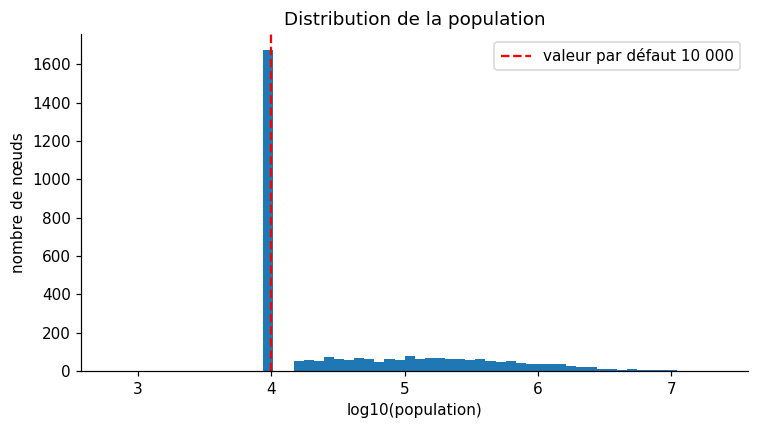

Part de valeurs par défaut dans les 10 pays les plus représentés :


,size,mean
country_clean,,
USA,650,0.44
CANADA,243,0.77
AUSTRALIA,207,0.73
BRAZIL,105,0.48
CHINA,93,0.13
PAPUA_NEW_GUINEA,92,0.87
RUSSIA,70,0.21
JAPAN,69,0.42
MEXICO,59,0.36


In [17]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(np.log10(pop), bins=60)
ax.axvline(np.log10(DEFAULT), color="red", ls="--", label="valeur par défaut 10 000")
ax.set(xlabel="log10(population)", ylabel="nombre de nœuds", title="Distribution de la population")
ax.legend(); plt.tight_layout(); plt.show()

print("Part de valeurs par défaut dans les 10 pays les plus représentés :")
(nodes.assign(is_default=pop == DEFAULT).groupby("country_clean")["is_default"]
      .agg(["size", "mean"]).sort_values("size", ascending=False).head(10).round(2))

In [18]:
# Homonymes : un même nom de ville associé à plusieurs aéroports
dup = nodes[nodes.duplicated("city_name", keep=False)].sort_values("city_name")
same_pop = dup.groupby("city_name")["population"].nunique() == 1
print(f"Noms de ville partagés par plusieurs aéroports : {dup['city_name'].nunique()}")
print(f"… dont avec une population identique (signe d'appariement par nom) : "
      f"{(same_pop & (dup.groupby('city_name')['population'].first() != DEFAULT)).sum()}")
dup[dup["population"] != DEFAULT][["city_name", "country_clean", "lat", "lon", "population", "degree"]].head(30)

Noms de ville partagés par plusieurs aéroports : 66
… dont avec une population identique (signe d'appariement par nom) : 61


,city_name,country_clean,lat,lon,population,degree
id,,,,,,
1483,Aberdeen,USA,45.449056,-98.421833,198590,3
1007,Aberdeen,UNITED_KINGDOM,57.204167,-2.200000,198590,20
505,Albany,AUSTRALIA,-34.950000,117.800000,33650,2
607,Albany,USA,31.535515,-84.194473,33650,1
609,Albany,USA,42.748119,-73.802979,33650,23
544,Athens,GREECE,37.918889,23.941111,664046,93
1172,Athens,USA,33.948595,-83.326347,664046,1
608,Augusta,USA,33.369944,-81.964500,30723,2
1153,Augusta,USA,44.320650,-69.797318,30723,2


In [19]:
logp = np.log10(pop)
r_all = stats.spearmanr(logp, nodes["degree"])
mask = pop != DEFAULT
r_clean = stats.spearmanr(logp[mask], nodes["degree"][mask])
print(f"Spearman(log pop, degré), tous les nœuds      : {r_all.statistic:.3f}")
print(f"Spearman(log pop, degré), sans valeurs défaut : {r_clean.statistic:.3f}")
print(f"Degré moyen : population par défaut {nodes['degree'][~mask].mean():.2f} | autres {nodes['degree'][mask].mean():.2f}")

Spearman(log pop, degré), tous les nœuds      : 0.350
Spearman(log pop, degré), sans valeurs défaut : 0.388
Degré moyen : population par défaut 4.49 | autres 11.59


In [20]:
# Lacune autour de la valeur par défaut : indice d'une base de villes à seuil minimal
non_default = pop[pop != DEFAULT]
print("Plus petite population hors valeur par défaut au-dessus de 10 000 :", non_default[non_default > DEFAULT].min())
print("Nombre de valeurs strictement comprises entre 10 000 et 15 000 :", ((pop > DEFAULT) & (pop < 15000)).sum())

Plus petite population hors valeur par défaut au-dessus de 10 000 : 10682
Nombre de valeurs strictement comprises entre 10 000 et 15 000 : 3


### Observation → décision (Q5)

**Observations.**
- 1 673 nœuds (49,7 %) ont une population de 10 000 exactement : il s'agit d'une valeur par défaut. Sa fréquence varie fortement selon le pays (87 % en Papouasie-Nouvelle-Guinée, 77 % au Canada, 13 % en Chine).
- Aucune population n'est comprise entre 10 000 et 10 682, et seules 3 valeurs se situent entre 10 000 et 15 000. Cette lacune suggère que les populations proviennent d'une base de villes dotée d'un seuil minimal, les villes non appariées recevant la valeur 10 000. Cette interprétation reste une hypothèse.
- Quelques valeurs sont aberrantes (902 pour Hamilton, 637 pour Jamestown).
- 66 noms de ville sont partagés par plusieurs aéroports ; parmi eux, 61 ont exactement la même population (par exemple Athens en Grèce et aux États-Unis : 664 046). Cela confirme un appariement fondé sur le seul nom de la ville.
- La corrélation entre log-population et degré est modérée (Spearman = 0,35 ; 0,39 hors valeurs par défaut).
- Les nœuds à valeur par défaut ont un degré moyen de 4,5, contre 11,6 pour les autres : l'absence de population est en elle-même informative.

**Décisions.**
- Utiliser log(population) plutôt que la valeur brute.
- Ajouter un indicateur binaire « population manquante » ; la valeur 10 000 est conservée pour ces nœuds, l'indicateur permettant au modèle de la distinguer.
- Conserver la population malgré le bruit lié aux homonymes ; son utilité réelle sera évaluée dans l'étude d'ablation.

## Q6 — Y a-t-il des erreurs d'étiquetage évidentes ?

**Hypothèse :** certaines villes ont reçu le mauvais pays ou les mauvaises coordonnées lors de l'appariement par nom.

**Test :** pour chaque aéroport, distance entre sa position et la position médiane des aéroports de son pays déclaré. Les valeurs extrêmes sont inspectées à la main. Un second indicateur compare la position de l'aéroport à celle de ses voisins dans le graphe.

In [21]:
med = nodes.groupby("country_clean")[["lat", "lon"]].median()
nodes["km_to_country_median"] = haversine(nodes["lat"], nodes["lon"],
                                          med.loc[cc, "lat"].values, med.loc[cc, "lon"].values)
cols = ["city_name", "country_clean", "lat", "lon", "population", "degree", "km_to_country_median"]
print("Aéroports les plus éloignés du centre de leur pays déclaré :")
nodes.sort_values("km_to_country_median", ascending=False)[cols].head(25).round(0)

Aéroports les plus éloignés du centre de leur pays déclaré :


,city_name,country_clean,lat,lon,population,degree,km_to_country_median
id,,,,,,,
75,Johnston Island,USA,17.0,-170.0,10000,2,6852.0
82,Midway Island,USA,28.0,-177.0,10000,1,6736.0
1648,Hagfors,USA,24.0,-166.0,10000,2,6101.0
78,Kauai Island,USA,22.0,-159.0,10000,6,5650.0
1114,Petropavlovsk-Kamchats,RUSSIA,53.0,159.0,10000,6,5628.0
8,Honolulu,USA,21.0,-158.0,371657,51,5577.0
79,Lanai City,USA,21.0,-157.0,10000,4,5534.0
77,Kona,USA,20.0,-156.0,10000,10,5532.0
83,Hoolehua,USA,21.0,-157.0,10000,3,5521.0


In [22]:
# Indicateur structurel : distance médiane d'un aéroport à ses voisins
nodes["median_km_to_neighbors"] = pd.Series({k: np.median(v) for k, v in node_dist.items()})
print("Aéroports de faible degré avec des voisins anormalement lointains :")
(nodes[nodes["degree"] <= 3].sort_values("median_km_to_neighbors", ascending=False)
      [cols[:-1] + ["median_km_to_neighbors"]].head(20).round(0))

Aéroports de faible degré avec des voisins anormalement lointains :


,city_name,country_clean,lat,lon,population,degree,median_km_to_neighbors
id,,,,,,,
3270,Matupa,PHILIPPINES,6.0,124.0,10000,2,19592.0
2422,Essaouira,MOROCCO,31.0,-10.0,70634,1,18334.0
2042,Plettenberg Bay,USA,41.0,-80.0,19445,1,18232.0
2044,Pietersburg,USA,37.0,-83.0,10000,1,18200.0
2360,Tortola,BRITISH_VIRGIN_ISLANDS,18.0,-65.0,10000,1,17946.0
2035,Margate,COLOMBIA,7.0,-73.0,60134,1,17269.0
3144,Hasvik,NEW_ZEALAND,-44.0,169.0,10000,2,16588.0
3031,Magdalena,AUSTRALIA,-12.0,134.0,16214,2,16438.0
2282,Praslin Island,SEYCHELLES,-4.0,56.0,10000,1,16384.0


In [23]:
# Vérification : pour les nœuds signalés, les voisins indiquent-ils la véritable localisation ?
name = nodes["city_name"]
suspects = nodes[nodes["degree"] <= 3].sort_values("median_km_to_neighbors", ascending=False).head(20)
for i, r in suspects.iterrows():
    neigh = [f"{name[v]} ({cc[v]})" for v in G[i]]
    print(f"{r.city_name:28} déclaré {r.country_clean:22} ({r.lat:6.1f}, {r.lon:7.1f}) → voisins : {', '.join(neigh)}")

Matupa                       déclaré PHILIPPINES            (   6.2,   124.3) → voisins : Sinop (BRAZIL), Itaituba (BRAZIL)
Essaouira                    déclaré MOROCCO                (  31.4,    -9.7) → voisins : Casablanca (AUSTRALIA)
Plettenberg Bay              déclaré USA                    (  40.5,   -80.2) → voisins : Johannesburg (AUSTRALIA)
Pietersburg                  déclaré USA                    (  36.7,   -83.0) → voisins : Johannesburg (AUSTRALIA)
Tortola                      déclaré BRITISH_VIRGIN_ISLANDS (  18.5,   -64.7) → voisins : St Thomas Island (AUSTRALIA)
Margate                      déclaré COLOMBIA               (   6.7,   -72.7) → voisins : Johannesburg (AUSTRALIA)
Hasvik                       déclaré NEW_ZEALAND            ( -43.9,   169.1) → voisins : Tromso (NORWAY), Hammerfest (NORWAY)
Magdalena                    déclaré AUSTRALIA              ( -12.1,   134.2) → voisins : Trinidad (BOLIVIA), San Joaquin (BOLIVIA)
Praslin Island               déclaré SEY

In [24]:
# Score de suspicion : distance médiane du nœud à ses voisins, rapportée à celle de ses voisins.
# Un nœud mal localisé est loin de tous ses voisins, alors que ses voisins sont proches des leurs ;
# le voisin innocent d'un nœud erroné, lui, conserve d'autres voisins proches.
neigh_med = pd.Series({u: np.median([nodes.at[v, "median_km_to_neighbors"] for v in G[u]]) for u in G})
nodes["suspicion"] = nodes["median_km_to_neighbors"] / (neigh_med + 1.0)

OUT = Path("outputs"); OUT.mkdir(exist_ok=True)
flag_cols = ["city_name", "country_clean", "lat", "lon", "degree", "median_km_to_neighbors", "suspicion"]
top = nodes.sort_values("suspicion", ascending=False)[flag_cols].head(30)
top.to_csv(OUT / "suspect_nodes.csv")
print("Liste exportée dans outputs/suspect_nodes.csv (à valider manuellement)")
top.round(2)

Liste exportée dans outputs/suspect_nodes.csv (à valider manuellement)


,city_name,country_clean,lat,lon,degree,median_km_to_neighbors,suspicion
id,,,,,,,
3204,Stronsay,USA,43.13,-96.19,3,6165.38,106.64
3201,Sanday,USA,38.33,-77.04,3,5566.20,96.28
2300,Sara,USA,58.17,-135.25,2,9687.47,87.85
2296,Green Island,USA,29.26,-89.96,1,13347.92,80.85
3293,Wasum,CANADA,62.23,-133.35,1,9959.28,77.77
3144,Hasvik,NEW_ZEALAND,-43.87,169.08,2,16588.35,68.15
2946,Alluitsup Paa,USA,37.49,-94.31,3,4223.39,57.89
2662,Portage Creek,MEXICO,20.08,-98.78,1,6388.55,56.91
3270,Matupa,PHILIPPINES,6.17,124.28,2,19591.95,56.02


### Observation → décision (Q6)

**Observations.**
- La distance au centre du pays déclaré produit essentiellement des faux positifs : les territoires éloignés mais correctement étiquetés (Hawaï, Aléoutiennes, Kamtchatka, îles Cocos). Ce détecteur est écarté.
- La distance médiane aux voisins identifie au contraire de véritables erreurs. L'examen des voisins montre que **les arêtes sont correctes, mais que les coordonnées et le pays du nœud sont erronés** : « Hasvik », placé en Nouvelle-Zélande, est relié à Tromsø et Hammerfest (Norvège) ; « Hagfors », placé dans le Pacifique, est relié à Stockholm ; « Pietersburg » et « Plettenberg Bay », placés aux États-Unis, sont reliés à Johannesburg ; « Camaguey », placé en Australie, est relié à La Havane ; « Burao », placé en Californie, est relié à Djibouti et Berbera.
- Ce détecteur signale aussi le voisin correctement localisé d'un nœud erroné : Essaouira est bien placée, mais son unique voisin « Casablanca » est localisé en Australie. Le score de suspicion ci-dessus, qui compare un nœud à ses voisins, permet de distinguer le nœud fautif de son voisin.
- Ce score de suspicion (rapport entre la distance du nœud à ses voisins et celle de ses voisins aux leurs) classe en tête des erreurs manifestes, que l'on peut vérifier par les voisins : Stronsay et Sanday (Orcades, Écosse) placées aux États-Unis, Joao Pessoa (Brésil) placée au Népal, Wewak (Papouasie) placée au Canada. Essaouira, voisin innocent, n'apparaît plus dans les 30 premiers.
- Les erreurs ne concernent pas seulement de petits aéroports : Ottawa (degré 26), Jersey (18), Cagliari (11) ou Cochabamba (6) sont localisés en Australie. Une erreur sur un nœud de degré élevé fausse la distance de nombreuses arêtes, ce qui renforce l'enjeu de la décision ci-dessous.

**Décisions.**
- Ne pas corriger ces nœuds, mais les signaler par un indicateur et les exporter (`outputs/suspect_nodes.csv`) : ils constituent une vérité terrain partielle pour le volet de détection d'anomalies.
- Ces erreurs faussent la distance des arêtes concernées. Leur effet sur la prédiction de liens sera soit neutralisé (exclusion des arêtes concernées de l'ensemble de test), soit mesuré explicitement. **Décision à arrêter avant l'écriture de `clean.py`.**

## Synthèse — observations et décisions

Ce tableau constitue la base de la section 3 du rapport.

| Question | Observation | Décision |
|---|---|---|
| Q0 | Graphe propre (ni boucle ni doublon) ; identifiants non contigus ; 9 chaînes de pays mal formées | Réindexation 0..N−1 avec table de correspondance ; normalisation des pays |
| Q1 | Clustering 220 fois supérieur à l'aléatoire ; assortativité quasi nulle (0,04) | Heuristiques CN et Adamic-Adar comme baselines ; hypothèse hub-and-spoke réfutée |
| Q2 | Degrés à queue lourde avec coupure ; 21,6 % de nœuds de degré 1 ; composante géante à 99,6 % | Baseline Preferential Attachment ; composante géante uniquement ; aucune arête unique d'un nœud en test |
| Q3 | Routes nettement plus courtes que les paires aléatoires (médiane 814 km contre 8 958 km ; D = 0,71) | Baseline « distance seule » ; distance dans le décodeur ; évaluation sur négatifs difficiles |
| Q4 | 57,4 % de routes domestiques contre 5,4 % attendus | Caractéristique de paire « même pays » ; embedding du pays comparé en ablation |
| Q5 | 49,7 % de populations par défaut ; homonymes partageant la même population ; défaut associé à un degré plus faible | log(population) et indicateur « population manquante » ; apport évalué en ablation |
| Q6 | Nœuds aux coordonnées et au pays erronés, arêtes correctes ; erreurs présentes y compris sur des nœuds de degré élevé ; score de suspicion fondé sur les voisins efficace | Signalement sans correction ; vérité terrain pour le volet anomalies ; traitement en test à décider |

**Décisions encore ouvertes avant `clean.py` :**
1. traitement des arêtes incidentes aux nœuds mal localisés dans l'ensemble de test ;
2. définition exacte des négatifs difficiles (seuil de distance ou plus proches voisins géographiques).